# 01 — Customer Segmentation with Clustering

This notebook builds a customer segmentation workflow.

The modelling goal is to discover useful behavioural groups without using predefined segment labels.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.data import make_customer_segmentation_data
from unsup_lab.evaluation import evaluate_clustering, evaluate_k_range
from unsup_lab.plotting import plot_embedding
from unsup_lab.preprocessing import scale_features
from unsup_lab.reporting import cluster_profile


## Generate customer behaviour data

In [2]:
dataset = make_customer_segmentation_data(n_customers=2_000, random_state=42)
features = dataset.features

features.head()


,recency_days,purchase_frequency,avg_order_value,discount_ratio,email_engagement,product_diversity
0,1.000000,40.540314,5.000000,0.317091,0.683116,0.676432
1,6.876079,1.000000,29.332878,0.221249,0.258808,0.183839
2,109.291088,4.847708,134.117057,0.191133,0.355464,0.300469
3,22.572693,29.298219,46.476565,0.188546,0.747382,0.817508
4,21.909348,24.853125,176.549213,0.122484,0.799835,0.661402


The hidden labels are kept only for later sanity checks. They are not used by the clustering models.


In [3]:
x_scaled = scale_features(features, method="standard")
x_scaled.describe().round(2)


,recency_days,purchase_frequency,avg_order_value,discount_ratio,email_engagement,product_diversity
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.92,-1.29,-1.29,-1.53,-2.37,-2.08
25%,-0.64,-0.87,-0.80,-0.74,-0.89,-0.91
50%,-0.37,-0.18,-0.24,-0.26,0.23,0.28
75%,0.06,0.78,0.63,0.43,0.80,0.79
max,2.64,2.58,2.96,2.64,1.86,2.10


## Compare different clustering assumptions

In [4]:
k_results = evaluate_k_range(
    x_scaled,
    estimator_factory=lambda k: KMeans(n_clusters=k, n_init=20, random_state=42),
    k_values=[2, 3, 4, 5, 6, 7, 8],
)

k_results


,k,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,2,2,0.405381,1.142318,1341.290177
1,3,3,0.448927,0.957036,1459.469089
2,4,4,0.530253,0.727970,1957.062211
3,5,5,0.619262,0.558631,3641.868539
4,6,6,0.513274,1.115936,3043.412742
5,7,7,0.416025,1.445764,2639.701362
6,8,8,0.318132,1.749631,2351.420644


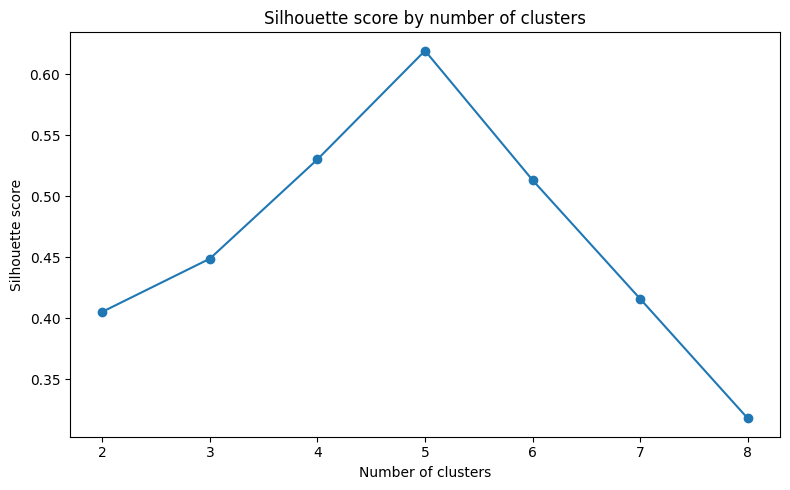

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["silhouette"], marker="o")
plt.title("Silhouette score by number of clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()


## Fit selected models

In [6]:
models = {
    "kmeans": KMeans(n_clusters=5, n_init=20, random_state=42),
    "gmm": GaussianMixture(n_components=5, random_state=42),
    "agglomerative": AgglomerativeClustering(n_clusters=5),
    "dbscan": DBSCAN(eps=1.2, min_samples=20),
}

labels_by_model = {}
for name, model in models.items():
    if hasattr(model, "fit_predict"):
        labels = model.fit_predict(x_scaled)
    else:
        labels = model.fit(x_scaled).predict(x_scaled)

    labels_by_model[name] = labels
    print(name, evaluate_clustering(x_scaled, labels))


kmeans ClusteringMetrics(n_clusters=5, silhouette=0.619261852604857, davies_bouldin=0.558630864494486, calinski_harabasz=3641.8685387047353)
gmm ClusteringMetrics(n_clusters=5, silhouette=0.619261852604857, davies_bouldin=0.558630864494486, calinski_harabasz=3641.8685387047353)


agglomerative ClusteringMetrics(n_clusters=5, silhouette=0.619261852604857, davies_bouldin=0.558630864494486, calinski_harabasz=3641.868538704735)
dbscan ClusteringMetrics(n_clusters=2, silhouette=0.24128258353320906, davies_bouldin=0.8666918363338915, calinski_harabasz=305.82045246961417)


## Visualise one selected solution

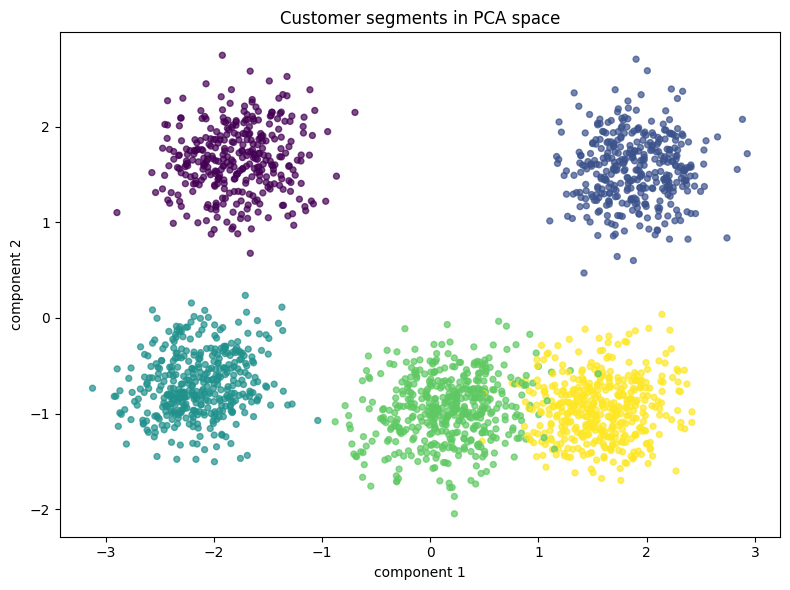

In [7]:
pca = PCA(n_components=2, random_state=42)
embedding = pca.fit_transform(x_scaled)
selected_labels = labels_by_model["kmeans"]

plot_embedding(embedding, selected_labels, title="Customer segments in PCA space")


## Segment profiling

In [8]:
profile = cluster_profile(features, selected_labels)
profile.round(2)


,recency_days,purchase_frequency,avg_order_value,discount_ratio,email_engagement,product_diversity,cluster_size
cluster,,,,,,,
0,110.01,7.57,113.66,0.20,0.38,0.29,335
1,18.30,23.82,187.85,0.12,0.82,0.75,369
2,12.05,3.41,35.73,0.28,0.21,0.17,399
3,33.32,13.85,73.09,0.72,0.62,0.58,467
4,10.29,36.05,30.50,0.33,0.73,0.66,430


## Interpretation

The output should be converted into business-readable segment cards.

Examples:

- High-value loyal customers.
- Discount-sensitive customers.
- Low-engagement new customers.
- Frequent low-value buyers.
- At-risk previous buyers.

These names should be validated with domain experts and operational data.


## Limitations

Clusters are not natural laws. They depend on feature selection, scaling, algorithm assumptions, and the chosen number of clusters. They should guide exploration and decision-making, not be treated as causal evidence.
